In [1]:
# Cell 1: Import all libraries and verify versions

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import cv2
import sqlite3
import pickle
import os
import sys

print("=" * 45)
print("   LIBRARY VERSION CHECK")
print("=" * 45)
print(f"Python      : {sys.version.split()[0]}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"SQLite3     : {sqlite3.sqlite_version}")
print(f"Pickle      : built-in ✅")
print("=" * 45)
print("✅ All libraries imported successfully")

   LIBRARY VERSION CHECK
Python      : 3.12.3
TensorFlow  : 2.19.0
Pandas      : 2.2.2
NumPy       : 1.26.4
Matplotlib  : 3.8.4
Scikit-learn: 1.5.1
OpenCV      : 4.11.0
SQLite3     : 3.45.1
Pickle      : built-in ✅
✅ All libraries imported successfully


In [2]:
# Cell 2: Check GPU/CPU availability

import tensorflow as tf

print("=" * 45)
print("   GPU / CPU CHECK")
print("=" * 45)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        print(f"✅ GPU found : {gpu.name}")
else:
    print("ℹ️  No GPU found - using CPU ✅")
    print("   This is expected for your setup")

cpus = tf.config.list_physical_devices('CPU')
print(f"✅ CPU found : {cpus[0].name}")

print("=" * 45)
print("✅ Hardware check complete")

   GPU / CPU CHECK
ℹ️  No GPU found - using CPU ✅
   This is expected for your setup
✅ CPU found : /physical_device:CPU:0
✅ Hardware check complete


In [3]:
# Cell 3: Verify all project folders exist

import os

BASE    = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR = f"{BASE}/data/images"
MODELS  = f"{BASE}/models"
PLOTS   = f"{BASE}/outputs/plots"
RESULTS = f"{BASE}/outputs/results"
DB_PATH = f"{BASE}/database/xray_metadata.db"

print("=" * 45)
print("   FOLDER STRUCTURE CHECK")
print("=" * 45)

folders_to_check = {
    "Base Project  " : BASE,
    "Data/Images   " : IMG_DIR,
    "Models        " : MODELS,
    "Outputs/Plots " : PLOTS,
    "Outputs/Result" : RESULTS,
    "Database      " : f"{BASE}/database",
    "Notebooks     " : f"{BASE}/notebooks",
    "Src           " : f"{BASE}/src",
}

all_good = True
for name, path in folders_to_check.items():
    if os.path.exists(path):
        print(f"✅ {name} : Found")
    else:
        print(f"❌ {name} : MISSING → {path}")
        all_good = False

print("=" * 45)
if all_good:
    print("✅ All 8 folders found")
else:
    print("⚠️  Some folders are missing!")
    print("   Creating missing folders now...")
    for name, path in folders_to_check.items():
        os.makedirs(path, exist_ok=True)
        print(f"   Created: {path}")
    print("✅ All folders created successfully")

   FOLDER STRUCTURE CHECK
✅ Base Project   : Found
✅ Data/Images    : Found
✅ Models         : Found
✅ Outputs/Plots  : Found
✅ Outputs/Result : Found
✅ Database       : Found
✅ Notebooks      : Found
✅ Src            : Found
✅ All 8 folders found


   IMAGE DISPLAY TEST


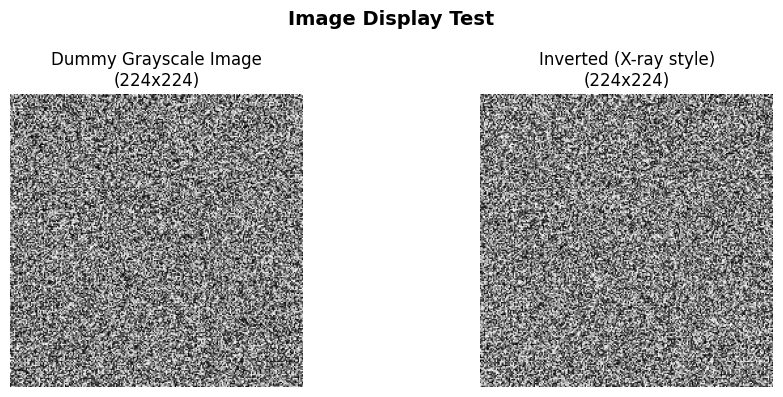

✅ Image shape     : (224, 224)
✅ Image dtype     : uint8
✅ Pixel min/max   : 0 / 255
✅ Image display working correctly


In [4]:
# Cell 4: Test dummy image display in notebook

import numpy as np
import matplotlib.pyplot as plt

print("=" * 45)
print("   IMAGE DISPLAY TEST")
print("=" * 45)

# Create a dummy grayscale image (224x224)
np.random.seed(42)
dummy_image = np.random.randint(0, 256, (224, 224), dtype=np.uint8)

# Display it
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Grayscale version
axes[0].imshow(dummy_image, cmap='gray')
axes[0].set_title("Dummy Grayscale Image\n(224x224)", fontsize=12)
axes[0].axis('off')

# Simulate X-ray look (dark background)
axes[1].imshow(255 - dummy_image, cmap='gray')
axes[1].set_title("Inverted (X-ray style)\n(224x224)", fontsize=12)
axes[1].axis('off')

plt.suptitle("Image Display Test", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Image shape     : {dummy_image.shape}")
print(f"✅ Image dtype     : {dummy_image.dtype}")
print(f"✅ Pixel min/max   : {dummy_image.min()} / {dummy_image.max()}")
print("=" * 45)
print("✅ Image display working correctly")

In [5]:
# Cell 5: Test DenseNet121 model loads correctly

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121

print("=" * 45)
print("   DENSENET121 LOADING TEST")
print("=" * 45)
print("Loading DenseNet121 with ImageNet weights...")
print("(First time may take 1-2 minutes to download)")
print()

# Load DenseNet121 base model
base_model = DenseNet121(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

# Count layers
total_layers = len(base_model.layers)

# Count parameters
total_params     = base_model.count_params()
total_params_M   = total_params / 1_000_000

print(f"✅ DenseNet121 loaded successfully")
print(f"✅ Total layers      : {total_layers}")
print(f"✅ Total parameters  : {total_params:,}")
print(f"✅ Parameters (M)    : {total_params_M:.2f} Million")
print()

# Check input and output shapes
print(f"✅ Input  shape      : {base_model.input_shape}")
print(f"✅ Output shape      : {base_model.output_shape}")
print()

# Verify layer 300 exists for fine-tuning later
if total_layers >= 300:
    print(f"✅ Layer 300 exists  : {base_model.layers[300].name}")
    print(f"✅ Fine-tuning ready : Layers 300+ can be unfrozen")
else:
    print(f"⚠️  Total layers only {total_layers} — check model")

print("=" * 45)
print("✅ DenseNet121 test complete")

# Clean up memory
del base_model
print("✅ Memory cleaned up")

   DENSENET121 LOADING TEST
Loading DenseNet121 with ImageNet weights...
(First time may take 1-2 minutes to download)

✅ DenseNet121 loaded successfully
✅ Total layers      : 427
✅ Total parameters  : 7,037,504
✅ Parameters (M)    : 7.04 Million

✅ Input  shape      : (None, 224, 224, 3)
✅ Output shape      : (None, 7, 7, 1024)

✅ Layer 300 exists  : conv4_block23_2_conv
✅ Fine-tuning ready : Layers 300+ can be unfrozen
✅ DenseNet121 test complete
✅ Memory cleaned up


In [6]:
# Cell 6: Test SQLite database works correctly

import sqlite3
import os

BASE    = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
DB_PATH = f"{BASE}/database/xray_metadata.db"

print("=" * 45)
print("   SQLITE DATABASE TEST")
print("=" * 45)

# Connect to database (creates file if not exists)
conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()
print(f"✅ Connected to database")
print(f"✅ DB Path : {DB_PATH}")

# Create a test table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS test_table (
        id      INTEGER PRIMARY KEY AUTOINCREMENT,
        name    TEXT,
        value   REAL
    )
""")
conn.commit()
print(f"✅ Test table created")

# Insert test rows
test_data = [
    ("accuracy",  0.9245),
    ("auc",       0.9512),
    ("precision", 0.8934),
    ("recall",    0.9123),
    ("f1_score",  0.9027),
]
cursor.executemany(
    "INSERT INTO test_table (name, value) VALUES (?, ?)",
    test_data
)
conn.commit()
print(f"✅ Test data inserted : {len(test_data)} rows")

# Query and display
cursor.execute("SELECT * FROM test_table")
rows = cursor.fetchall()
print()
print(f"   {'ID':<5} {'Metric':<12} {'Value':<10}")
print(f"   {'-'*5} {'-'*12} {'-'*10}")
for row in rows:
    print(f"   {row[0]:<5} {row[1]:<12} {row[2]:<10.4f}")

# Drop test table (cleanup)
cursor.execute("DROP TABLE IF EXISTS test_table")
conn.commit()
print()
print(f"✅ Test table dropped (cleanup done)")

# Check DB file exists
if os.path.exists(DB_PATH):
    size_kb = os.path.getsize(DB_PATH) / 1024
    print(f"✅ DB file exists     : {size_kb:.1f} KB")

# Close connection
conn.close()
print(f"✅ Connection closed")
print("=" * 45)
print("✅ SQLite test complete")

   SQLITE DATABASE TEST
✅ Connected to database
✅ DB Path : D:/Projects/Harsh_Mini_Project/medical_xray_project/database/xray_metadata.db
✅ Test table created
✅ Test data inserted : 5 rows

   ID    Metric       Value     
   ----- ------------ ----------
   1     accuracy     0.9245    
   2     auc          0.9512    
   3     precision    0.8934    
   4     recall       0.9123    
   5     f1_score     0.9027    

✅ Test table dropped (cleanup done)
✅ DB file exists     : 12.0 KB
✅ Connection closed
✅ SQLite test complete


In [8]:
import os

KAGGLE_PATH = "D:/chest_xray"

print("=" * 55)
print("   CHEST_XRAY FOLDER STRUCTURE SCAN")
print("=" * 55)

for root, dirs, files in os.walk(KAGGLE_PATH):
    # Calculate depth for indentation
    depth  = root.replace(KAGGLE_PATH, '').count(os.sep)
    indent = '   ' * depth
    folder = os.path.basename(root)
    
    # Count images in this folder
    images = [f for f in files if f.lower().endswith(
                ('.png', '.jpg', '.jpeg'))]
    
    if depth == 0:
        print(f"{indent}📁 {folder}/")
    else:
        if images:
            print(f"{indent}📂 {folder}/  ← {len(images)} images")
        else:
            print(f"{indent}📂 {folder}/")

print("=" * 55)
print("✅ Scan complete")

   CHEST_XRAY FOLDER STRUCTURE SCAN
📁 chest_xray/
   📂 chest_xray/
      📂 test/
         📂 NORMAL/  ← 234 images
         📂 PNEUMONIA/  ← 390 images
      📂 train/
         📂 NORMAL/  ← 1341 images
         📂 PNEUMONIA/  ← 3875 images
      📂 val/
         📂 NORMAL/  ← 8 images
         📂 PNEUMONIA/  ← 8 images
✅ Scan complete
